# Visualização de Focus de Modelos

### Notebook para Carregar e Visualizar, Via Mapas de Calor, o Foco dos Modelos nas Imagens

In [3]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image


def _resolve_project_root():
    """Sobe diretórios até encontrar utils/models_to_pkl.py (não depende do cwd do Jupyter)."""
    here = Path.cwd().resolve()
    for base in [here, *here.parents]:
        if (base / "utils" / "models_to_pkl.py").is_file():
            return str(base)
    raise FileNotFoundError("Raiz do repositório não encontrada (esperado utils/models_to_pkl.py).")


project_root = _resolve_project_root()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from utils.gradcam import find_last_spatial_layer_name, make_gradcam_heatmap, overlay_jet_on_rgb
from utils.models_to_pkl import load_model
from utils.tf_gpu import configure_gpu_memory_growth, log_gpu_status

configure_gpu_memory_growth()
log_gpu_status()

from utils.visualization_samples import (
    format_probs_percent,
    list_val_rgb_images,
    predicted_class,
    shuffle_samples,
)



TensorFlow devices
  GPU count: 1
  [0] /physical_device:GPU:0
  CPU count: 1



[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
# Treino e Grad-CAM usam TensorFlow; GPUs visíveis ao TF estão no log da célula anterior.


In [4]:
# Padrão: transferência ResNet50 em RGB sobre dados raw (alinhado a train_images_binary em JPG).
# Sobrescreva com CO2WOUNDS_MODEL se tiver outro .keras em models/.
_model_base = os.environ.get("CO2WOUNDS_MODEL", "modelo_binario_co2wounds_transfer_raw")
model_path = os.path.join(project_root, "models", _model_base)
model = load_model(model_path)


✅ Modelo carregado de: /home/alyssandro/Documentos/Github/leprosy_classification_models-TCC/models/modelo_binario_co2wounds_transfer_raw.keras


## Modelos RGB com ResNet50 (ImageNet): entrada `(1, 224, 224, 3)` + `preprocess_input`


In [5]:
def get_img_array(img_path, size=(224, 224)):
    img = image.load_img(img_path, target_size=size)
    array = image.img_to_array(img)
    array = np.expand_dims(array, axis=0)
    array = tf.keras.applications.resnet50.preprocess_input(array)
    return tf.constant(array, dtype=tf.float32)


def display_gradcam(img_path, heatmap, true_class, pred_class, probs, alpha=0.5, gamma=2.0, percentile=80):
    img = image.load_img(img_path, target_size=(224, 224))
    rgb = np.asarray(img, dtype=np.uint8)
    overlay = overlay_jet_on_rgb(rgb, heatmap, alpha=alpha, gamma=gamma, percentile=percentile)
    plt.figure(figsize=(12, 6))
    plt.suptitle(
        f"Classe real: {true_class} | Classe prevista: {pred_class}\n{format_probs_percent(probs)}",
        fontsize=11,
    )
    plt.subplot(1, 2, 1)
    plt.title("Imagem original (224×224)")
    plt.imshow(rgb)
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.title("Grad-CAM")
    plt.imshow(overlay)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [6]:
for i, layer in enumerate(model.layers): # Achando o nome da última camada convolucional
    try:
        print(f"{i}: {layer.name} -> {layer.output_shape}")
    except AttributeError:
        print(f"{i}: {layer.name} -> (sem output_shape)")


0: input_layer -> (sem output_shape)
1: conv1_pad -> (sem output_shape)
2: conv1_conv -> (sem output_shape)
3: conv1_bn -> (sem output_shape)
4: conv1_relu -> (sem output_shape)
5: pool1_pad -> (sem output_shape)
6: pool1_pool -> (sem output_shape)
7: conv2_block1_1_conv -> (sem output_shape)
8: conv2_block1_1_bn -> (sem output_shape)
9: conv2_block1_1_relu -> (sem output_shape)
10: conv2_block1_2_conv -> (sem output_shape)
11: conv2_block1_2_bn -> (sem output_shape)
12: conv2_block1_2_relu -> (sem output_shape)
13: conv2_block1_0_conv -> (sem output_shape)
14: conv2_block1_3_conv -> (sem output_shape)
15: conv2_block1_0_bn -> (sem output_shape)
16: conv2_block1_3_bn -> (sem output_shape)
17: conv2_block1_add -> (sem output_shape)
18: conv2_block1_out -> (sem output_shape)
19: conv2_block2_1_conv -> (sem output_shape)
20: conv2_block2_1_bn -> (sem output_shape)
21: conv2_block2_1_relu -> (sem output_shape)
22: conv2_block2_2_conv -> (sem output_shape)
23: conv2_block2_2_bn -> (sem outp

Grad-CAM usando camada: conv5_block3_out
IMG1000.jpg


/home/alyssandro/Documentos/Github/leprosy_classification_models-TCC/.venv/lib/python3.10/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)
I0000 00:00:1778778117.729442  901578 cuda_dnn.cc:461] Loaded cuDNN version 92200


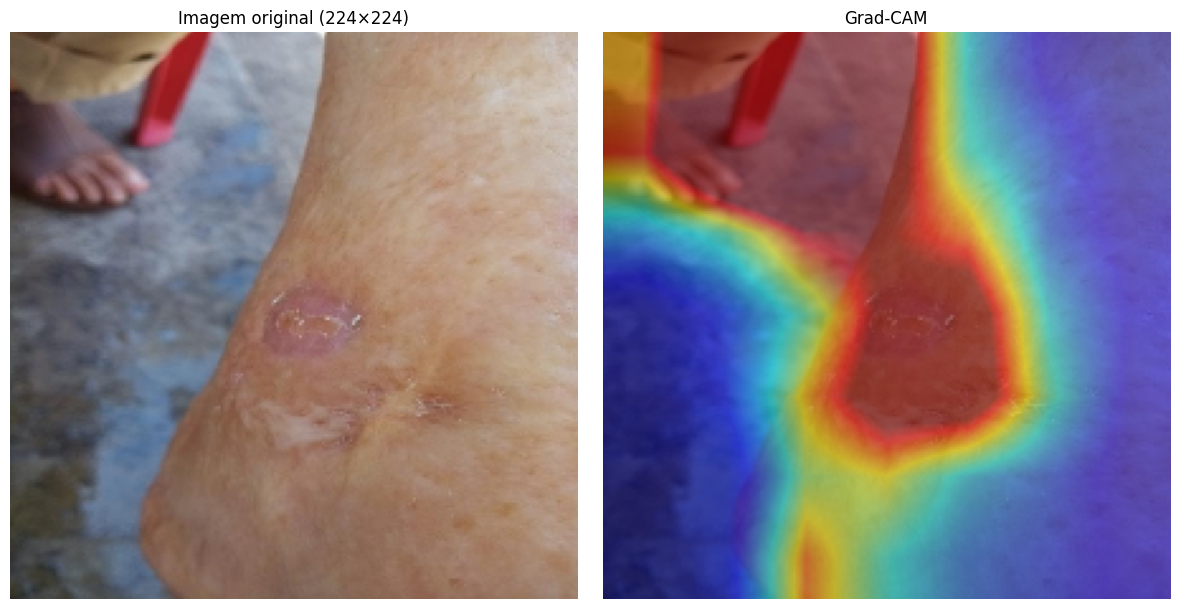

IMG1001.jpg


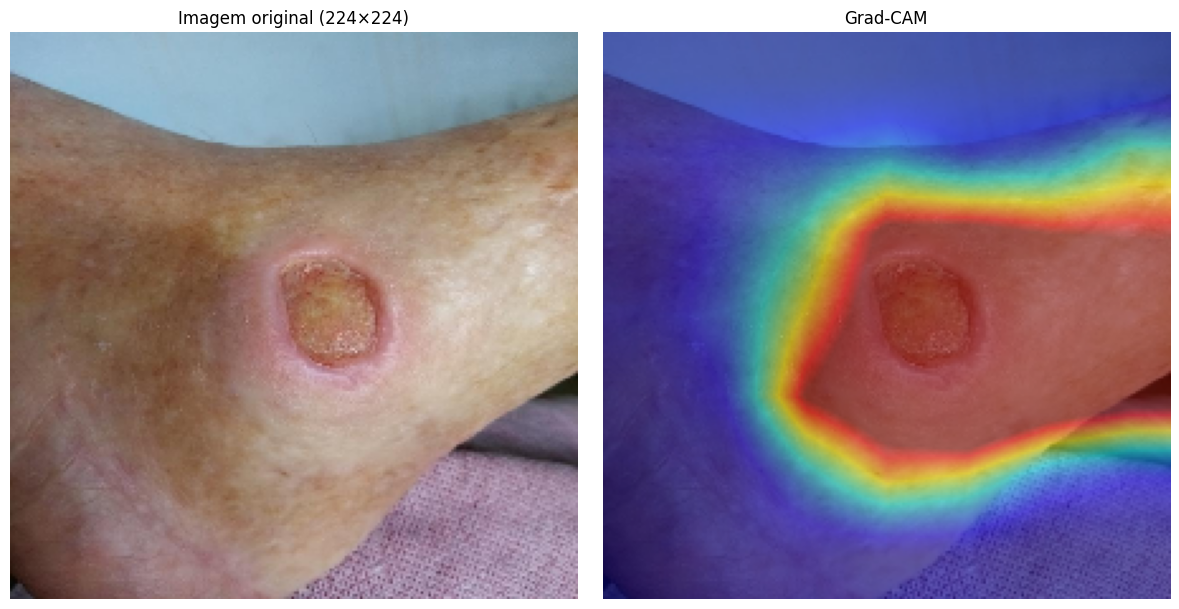

IMG1002.jpg


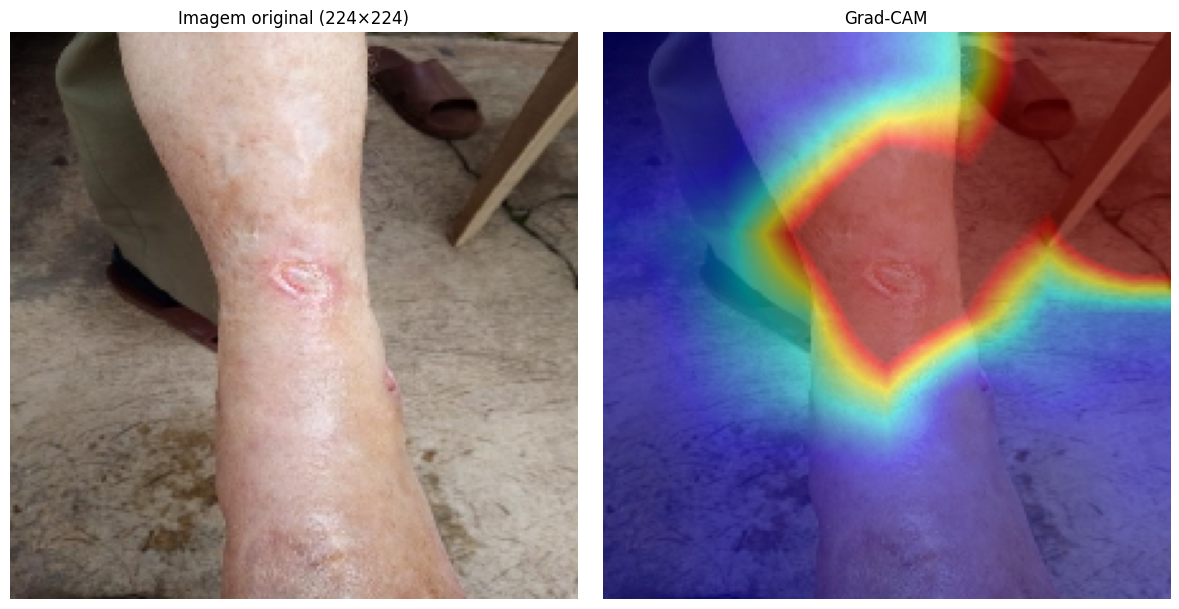

IMG1004.jpg


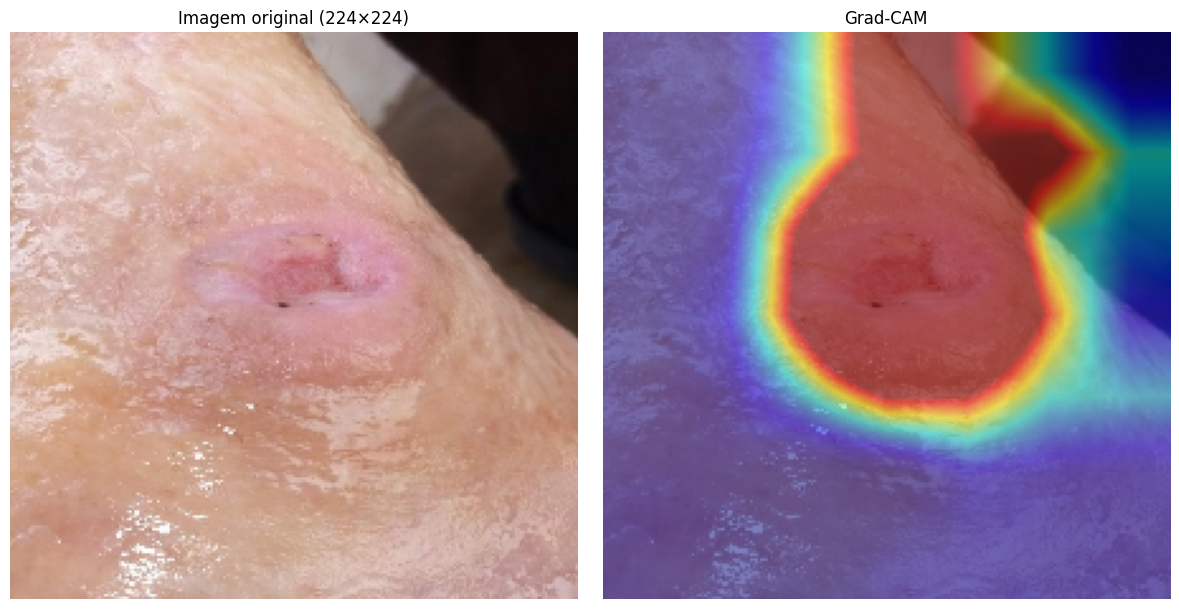

IMG1006.jpg


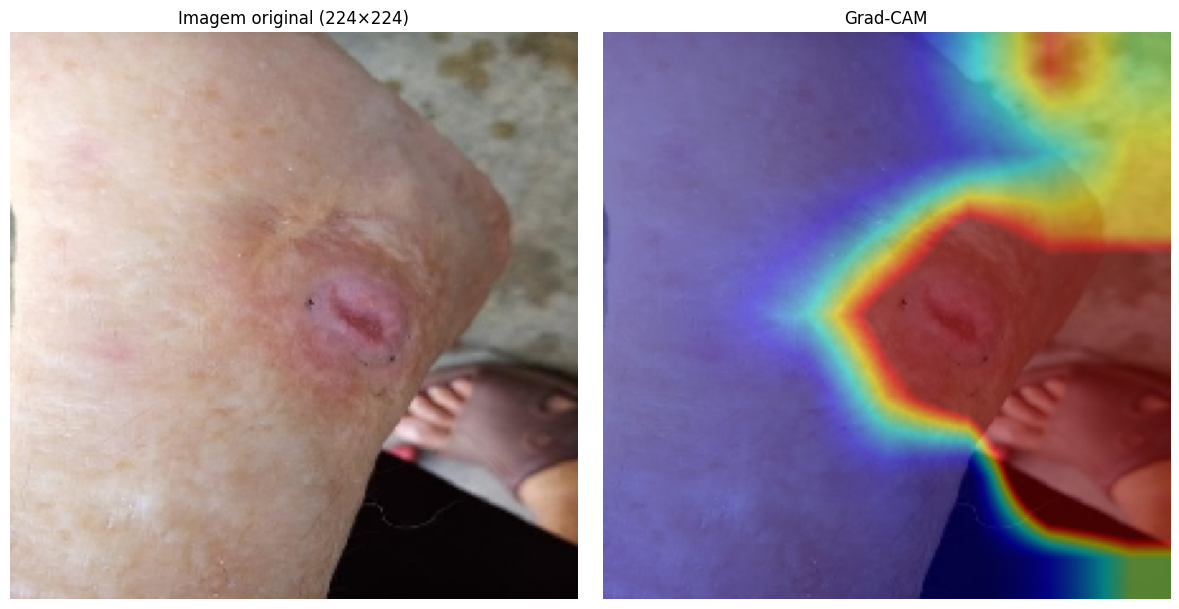

IMG1007.jpg


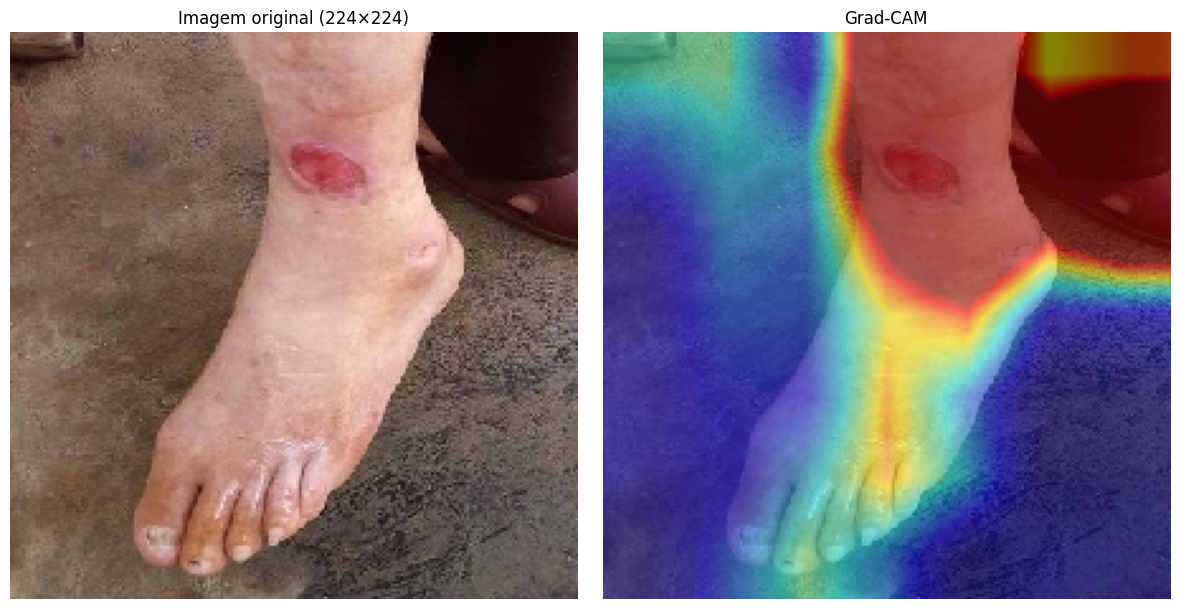

IMG1009.jpg


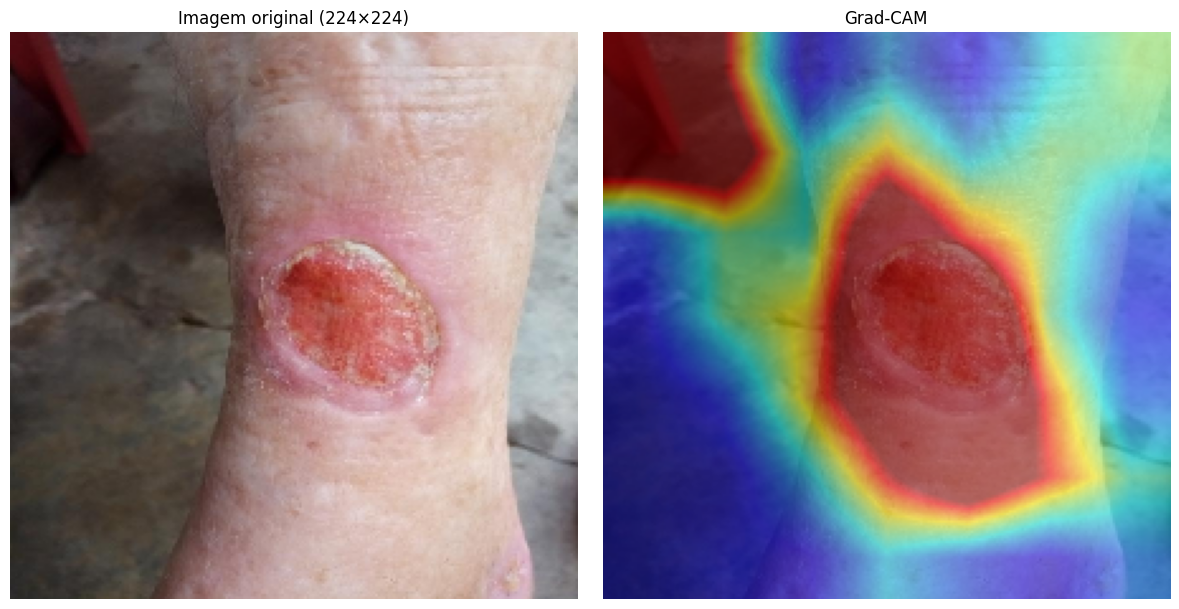

IMG1011.jpg


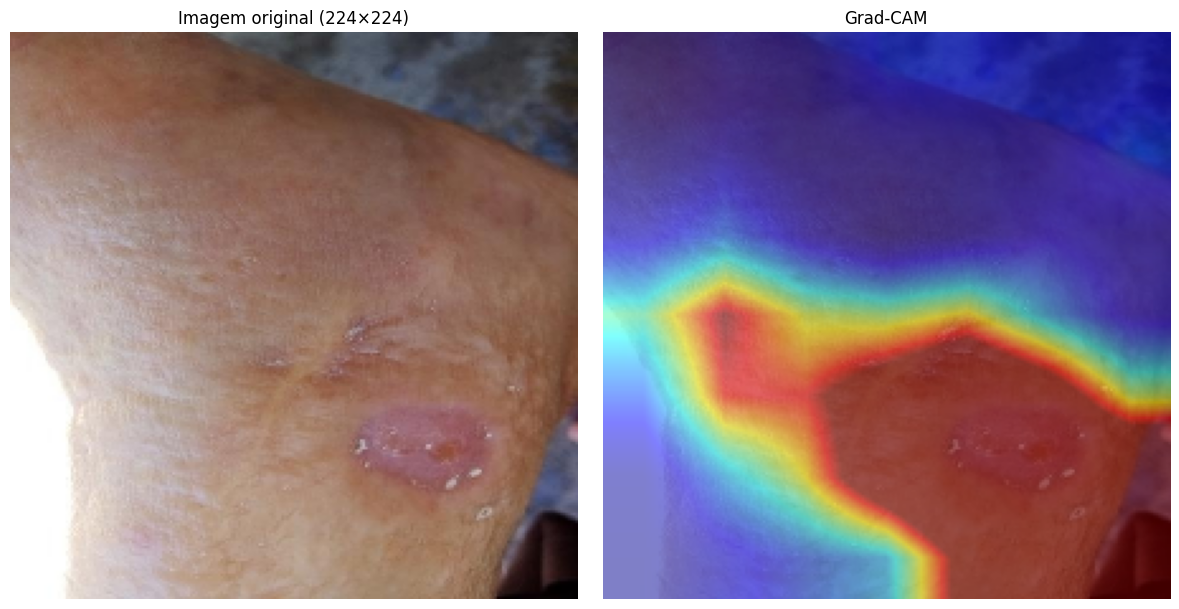

IMG1014.jpg


In [ ]:
VAL_ROOT = os.path.join(
    project_root, "data", "CO2Wounds-V2", "raw", "train_images_binary", "val"
)
SHUFFLE_SEED = 42  # None para ordem aleatória diferente a cada execução
MAX_IMAGES = None  # inteiro para limitar após embaralhar

LAST_CONV = find_last_spatial_layer_name(model)
print("Grad-CAM usando camada:", LAST_CONV)

samples = list_val_rgb_images(VAL_ROOT)
if not samples:
    raise FileNotFoundError(f"Nenhuma imagem em {VAL_ROOT}/leprosy ou .../outros")

samples = shuffle_samples(samples, seed=SHUFFLE_SEED)
if MAX_IMAGES is not None:
    samples = samples[: int(MAX_IMAGES)]

print(f"Processando {len(samples)} imagem(ns) de val (leprosy + outros), embaralhadas.")

for stem, img_path, true_class in samples:
    img_array = get_img_array(img_path, size=(224, 224))
    probs = model.predict(img_array, verbose=0)[0]
    pred_class = predicted_class(probs)
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name=LAST_CONV)
    print(f"\033[94m{stem}\033[m — real: {true_class} | prevista: {pred_class}")
    display_gradcam(img_path, heatmap, true_class, pred_class, probs)


In [ ]:
# Probabilidades da última imagem processada (se a célula anterior foi executada):
try:
    print("Probabilidades:", probs)
    print(format_probs_percent(probs))
    print(f"Classe real: {true_class} | Classe prevista: {pred_class}")
except NameError:
    print("Execute a célula anterior primeiro.")
